<a href="https://colab.research.google.com/github/websterj3-sketch/QLC140Spring26/blob/main/Exercise4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Install the packages needed
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
!pip install netcdf4
import netCDF4 as nc
import urllib.request as urllib2

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 68.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 73.7 MB/s eta 0:00:00


Below we are going to plot data from an ocean glider. Search the web.

1. What is an ocean glider?
- An ocean glider is an automous, unmanned vehicle designed to collect oceanographic data over long distances and extended periods without human interaction.
2. How does it move?
- Ocean gliders move by changing their buoyancy using a pump system to adjust the volume of an oil-filled bladder. This allows them to rise and sink.



,unixtime,lat,lon,depth,sci_water_sal
0,1370530681.4415,44.533653577385195,-63.393453793673935,35.2,31.852892253513247
1,1370530742.2388,44.53351946378085,-63.39334395323845,26.06,31.717310598606883
2,1370530802.37628,44.53338680568273,-63.39323530487769,17.29,31.462472169658824
3,1370530863.38712,44.5332522210279,-63.39312507864697,8.83,31.127901282228475
4,1370530924.34824,44.53311774605122,-63.39301494224378,2.14,31.03919875193208
5,1370530984.70169,44.532984611541806,-63.392905903697226,0.08,31.063125057254904
6,1370531045.39243,44.53306864305745,-63.39281438058511,0.1,31.068870156872823
7,1370531231.35141,44.53335101272887,-63.39261076649543,0.14,31.071476339509058
8,1370531291.78391,44.53343234998684,-63.39255392329026,0.10999999999999999,31.072580432046948
9,1370531352.96957,44.53352163729203,-63.39248195918229,0.10999999999999999,31.072580432046948


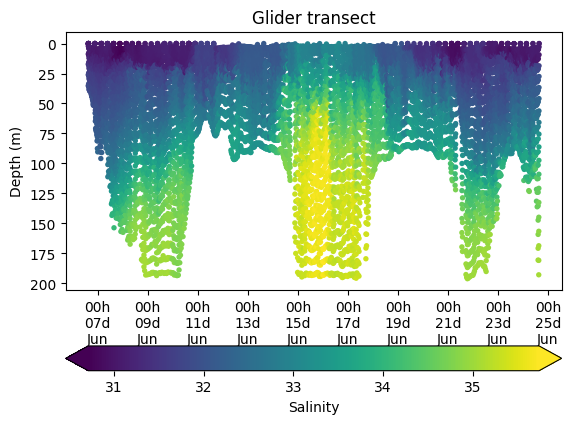

In [ ]:
import csv
import matplotlib.pyplot as plt
import matplotlib.dates as md
import datetime
from io import StringIO
# Retrieve data from the "glider" server
response = urllib2.urlopen('http://glider.ceotr.ca/data/live/otn200_sci_water_sal_live.csv')
data = response.read().decode('utf-8') # Decode the response to a string

# Use StringIO to create a file-like object from the string data
data_stream = StringIO(data)

# Read file
r = csv.DictReader(data_stream)

# Print top 10 lines of dataframe
df = pd.DataFrame(list(r))
display(df.head(10))

# Convert relevant columns to numeric type and extract for plotting
df['unixtime'] = pd.to_numeric(df['unixtime'])
df['lat'] = pd.to_numeric(df['lat'])
df['lon'] = pd.to_numeric(df['lon'])
df['depth'] = pd.to_numeric(df['depth'])
df['sci_water_sal'] = pd.to_numeric(df['sci_water_sal'])

date_unix = df['unixtime'].to_list()
lat = df['lat'].to_list()
lon = df['lon'].to_list()
depth = df['depth'].to_list()
salinity = df['sci_water_sal'].to_list()

# Change unix-time into a date object (for easy plotting)
DATE = [datetime.datetime.fromtimestamp(ts) for ts in date_unix]

# Make plot
fig, ax1 = plt.subplots(1)
plt.scatter(DATE,depth,s=15,c=salinity,marker='o',edgecolor='none')
#plt.ylim(-0.5,max(depth)+5))
ax1.set_ylim(ax1.get_ylim()[::-1])
cbar = plt.colorbar(orientation='horizontal', extend='both')
xfmt = md.DateFormatter('%Hh\n%dd\n%b') # Corrected: used md instead of date
ax1.xaxis.set_major_formatter(xfmt)
cbar.set_label('Salinity')
plt.title('Glider transect')
plt.ylabel('Depth (m)')
plt.show()

In [ ]:
# Install cmocean package
!pip install cmocean
# Import cmoceaon package
import cmocean

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 421.9/421.9 kB 8.9 MB/s eta 0:00:00


,unixtime,lat,lon,depth,sci_water_temp
0,1370530254.25809,44.534030000000001,-63.393878333300002,0.083147499999999999,0.0
1,1370530355.41907,44.534115,-63.393787304973607,0.79591684226945247,0.0
2,1370530416.23221,44.534238606222544,-63.39393293837054,4.3112462371670102,9.0907
3,1370530620.40247,44.533788224224502,-63.393564070834394,38.666863442968072,0.0
4,1370530681.4415,44.533653577385195,-63.393453793673935,34.513875660512575,3.3461
5,1370530742.2388,44.533519463780848,-63.39334395323845,25.014983891599616,3.8327
6,1370530802.37628,44.533386805682731,-63.393235304877692,16.012906763391015,4.561
7,1370530863.38712,44.533252221027901,-63.393125078646968,7.4561360083913684,7.8735
8,1370530924.34824,44.533117746051218,-63.393014942243781,1.5124172661925932,8.5417
9,1370530984.70169,44.532984611541806,-63.392905903697226,0.026494864961933016,9.2214


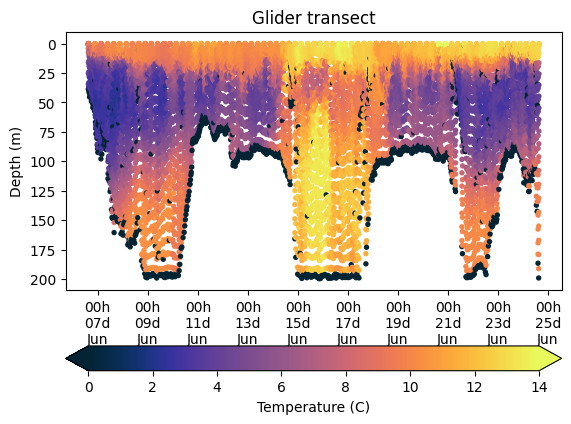

In [ ]:
import csv
import matplotlib.pyplot as plt
import matplotlib.dates as md
import datetime
from io import StringIO
# Retrieve data from the "glider" server
response = urllib2.urlopen('http://glider.ceotr.ca/data/live/otn200_sci_water_temp_live.csv')
data = response.read().decode('utf-8') # Decode the response to a string

# Use StringIO to create a file-like object from the string data
data_stream = StringIO(data)

# Read file
r = csv.DictReader(data_stream)

# Print top 10 lines of dataframe
df = pd.DataFrame(list(r))
display(df.head(10))

# Convert relevant columns to numeric type and extract for plotting
df['unixtime'] = pd.to_numeric(df['unixtime'])
df['lat'] = pd.to_numeric(df['lat'])
df['lon'] = pd.to_numeric(df['lon'])
df['depth'] = pd.to_numeric(df['depth'])
df['sci_water_temp'] = pd.to_numeric(df['sci_water_temp'])

date_unix = df['unixtime'].to_list()
lat = df['lat'].to_list()
lon = df['lon'].to_list()
depth = df['depth'].to_list()
salinity = df['sci_water_temp'].to_list()

# Change unix-time into a date object (for easy plotting)
DATE = [datetime.datetime.fromtimestamp(ts) for ts in date_unix]

# Make plot
fig, ax1 = plt.subplots(1)
plt.scatter(DATE,depth,s=15,c=salinity,marker='o',edgecolor='none',cmap=cmocean.cm.thermal)
#plt.ylim(-0.5,max(depth)+5))
ax1.set_ylim(ax1.get_ylim()[::-1])
cbar = plt.colorbar(orientation='horizontal', extend='both')
xfmt = md.DateFormatter('%Hh\n%dd\n%b') # Corrected: used md instead of date
ax1.xaxis.set_major_formatter(xfmt)
cbar.set_label('Temperature (C)')
plt.title('Glider transect')
plt.ylabel('Depth (m)')
plt.show()




1. What does this figure show you?
The data for temperature that the glider measured on this water column based on depth and date.
2. What can we gather from both of these figures about the water column?
Deeper depths have higher temperatures and higher salinity, while more shallow waters have lower temperatures and lower salinities.
3. Why might gliders be useful for atmospheric and ocean circulation models/predictions?
Gliders are versatile and can operate for months, meaning they can easily carry out sampling over large areas.
4. What is cmocean? Search the web.
Colormaps designed specifically for oceanographic data visualization.
5. Why is the color scheme important to figure visualization of data?
The different color schemes of the temperature vs salinity figures help for differentiating the factors and makes it easier for recollection without mixing them up.